Gen 50, Pareto size = 10
Gen 100, Pareto size = 12
Gen 150, Pareto size = 4
Gen 200, Pareto size = 4
Gen 250, Pareto size = 4
Gen 300, Pareto size = 4

 FINAL PARETO SOLUTIONS 
Total Pareto solutions: 4
Solution 1: [13268.67802015  8333.76327167  7895.86359758]
Solution 2: [13324.76828761 10004.32689183  5312.70623325]
Solution 3: [14360.95383038  9998.09429638  6980.5752544 ]
Solution 4: [18339.54067362 15319.31652986  4832.35863002]

 MULTI-OBJECTIVE METRICS 
Hypervolume = 1.2578
IGD         = 0.2144
Spread      = 0.2757


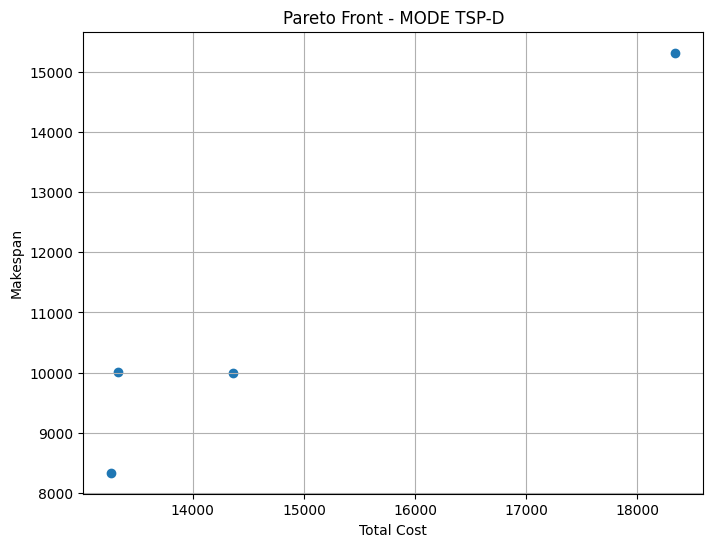

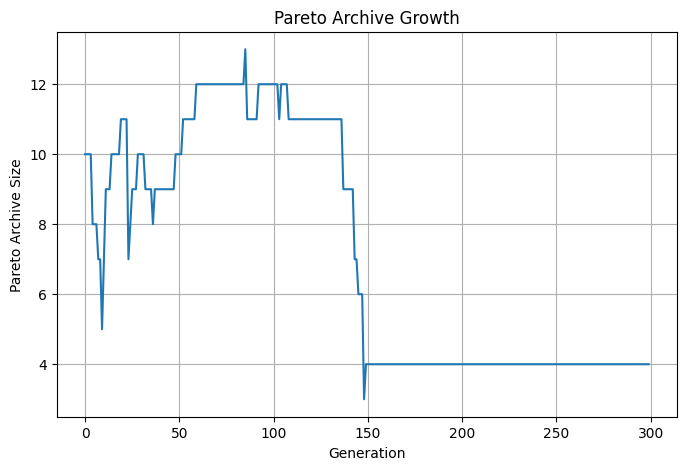

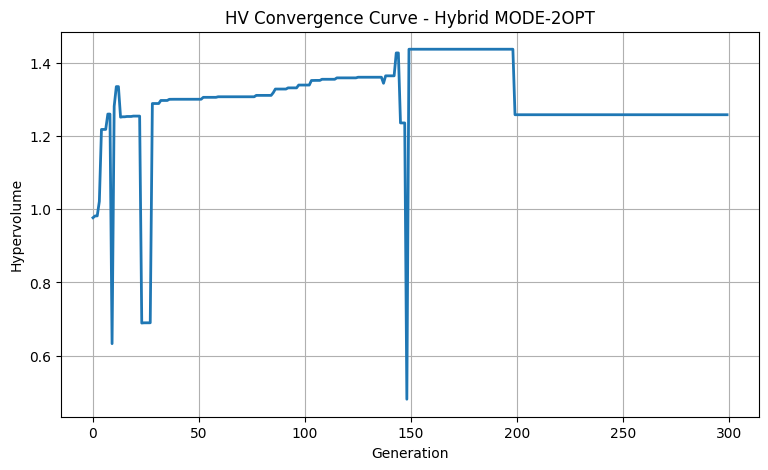

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
# READ TSPLIB
def read_tsp(file_path):
    coords = []
    start = False

    with open(file_path, "r") as f:
        for line in f:
            if "NODE_COORD_SECTION" in line:
                start = True
                continue
            if "EOF" in line:
                break
            if start:
                parts = line.strip().split()
                coords.append([float(parts[1]), float(parts[2])])

    return np.array(coords)


# DIST MATRIX
def compute_dist_matrix(coords):
    N = len(coords)
    dist = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            dist[i, j] = np.linalg.norm(coords[i] - coords[j])

    return dist


# DECODE
def decode(ind):
    return np.argsort(ind)


# PARAMETERS
DRONE_RANGE = 1500
DRONE_SPEED = 1.8
TRUCK_SPEED = 1.0
WAIT_TIME = 5
ENERGY_RATE = 0.8
DRONE_COST_RATE = 0.5
TRUCK_COST_RATE = 1.0


# MULTI OBJECTIVE FITNESS
def tspd_multi_objective(route, dist):
    total_cost = 0.0
    truck_time = 0.0
    drone_time = 0.0
    drone_energy = 0.0

    i = 0
    N = len(route)

    while i < N - 1:
        a = route[i]
        b = route[i + 1]

        if i < N - 2:
            c = route[i + 2]

            truck_dist = dist[a, c]
            drone_dist = dist[a, b] + dist[b, c]
            saving = dist[a, b] + dist[b, c] - dist[a, c]

            #  USE DRONE 
            if drone_dist <= DRONE_RANGE and saving > 10:
                total_cost += (
                    TRUCK_COST_RATE * truck_dist +
                    DRONE_COST_RATE * drone_dist
                )

                truck_time += truck_dist / TRUCK_SPEED
                drone_time += drone_dist / DRONE_SPEED + WAIT_TIME
                drone_energy += drone_dist * ENERGY_RATE

                i += 2
                continue

        #  TRUCK ONLY 
        total_cost += TRUCK_COST_RATE * dist[a, b]
        truck_time += dist[a, b] / TRUCK_SPEED
        i += 1

    makespan = max(truck_time, drone_time)

    return np.array([
        total_cost,
        makespan,
        drone_energy
    ])


# DOMINANCE
def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)


# DUPLICATE CHECK
def is_duplicate(candidate_fit, archive, tol=1e-6):
    for sol in archive:
        if np.allclose(candidate_fit, sol["fitness"], atol=tol):
            return True
    return False


# 2-OPT
def two_opt(route, dist, max_iter=5):
    best = route.copy()
    best_fit = tspd_multi_objective(best, dist)

    for _ in range(max_iter):
        improved = False

        for i in range(1, len(route) - 2):
            for j in range(i + 2, len(route)):
                new_route = best.copy()
                new_route[i:j] = best[j - 1:i - 1:-1]

                new_fit = tspd_multi_objective(new_route, dist)

                if dominates(new_fit, best_fit):
                    best = new_route
                    best_fit = new_fit
                    improved = True

        if not improved:
            break

    return best


# MODE MAIN
def MODE_tspd(coords, NP=60, F=0.8, CR=0.9, GEN=1000):
    dist = compute_dist_matrix(coords)
    N = len(coords)

    pop = np.random.rand(NP, N)

    fitness_vals = np.array([
        tspd_multi_objective(decode(ind), dist)
        for ind in pop
    ])

    pareto_archive = []
    archive_history = []
    hv_history = []

    for g in range(1, GEN + 1):
        for i in range(NP):
            idxs = [j for j in range(NP) if j != i]
            r1, r2, r3 = pop[np.random.choice(idxs, 3, replace=False)]

            #  MUTATION 
            v = np.clip(r1 + F * (r2 - r3), 0, 1)

            #  CROSSOVER 
            u = pop[i].copy()
            j_rand = np.random.randint(N)

            for j in range(N):
                if np.random.rand() < CR or j == j_rand:
                    u[j] = v[j]

            u_route = decode(u)
            u_fit = tspd_multi_objective(u_route, dist)

            if dominates(u_fit, fitness_vals[i]):
                pop[i] = u
                fitness_vals[i] = u_fit

        #  LOCAL SEARCH 
        if g > 100 and g % 50 == 0:
            for i in range(NP):
                route = decode(pop[i])
                improved_route = two_opt(route, dist)
                improved_fit = tspd_multi_objective(improved_route, dist)

                if dominates(improved_fit, fitness_vals[i]):
                    pop[i] = np.random.rand(N)
                    fitness_vals[i] = improved_fit

        #  UPDATE ARCHIVE 
        for i in range(NP):
            candidate_fit = fitness_vals[i]
            candidate_route = decode(pop[i])

            if is_duplicate(candidate_fit, pareto_archive):
                continue

            dominated = False
            to_remove = []

            for j, sol in enumerate(pareto_archive):
                if dominates(sol["fitness"], candidate_fit):
                    dominated = True
                    break

                if dominates(candidate_fit, sol["fitness"]):
                    to_remove.append(j)

            if not dominated:
                for idx in reversed(to_remove):
                    pareto_archive.pop(idx)

                pareto_archive.append({
                    "route": candidate_route.copy(),
                    "fitness": candidate_fit.copy()
                })

        archive_history.append(len(pareto_archive))
        #  HV HISTORY 
        if len(pareto_archive) > 1:
            hv_value, _, _ = evaluate_metrics(pareto_archive)
            hv_history.append(hv_value)
        else:
            hv_history.append(0)
        if g % 50 == 0:
            print(f"Gen {g}, Pareto size = {len(pareto_archive)}")

    return pareto_archive, archive_history, hv_history, dist

# METRICS
def spread_metric(F):
    if len(F) < 2:
        return 0

    F = F[F[:, 0].argsort()]
    distances = np.linalg.norm(F[1:] - F[:-1], axis=1)

    d_mean = np.mean(distances)
    if d_mean == 0:
        return 0

    return np.sum(np.abs(distances - d_mean)) / (
        len(distances) * d_mean
    )


def evaluate_metrics(archive, reference_front=None):
    F = np.array([sol["fitness"] for sol in archive])

    #  normalize 
    F_min = F.min(axis=0)
    F_max = F.max(axis=0)
    F_norm = (F - F_min) / (F_max - F_min + 1e-9)

    #  Hypervolume 
    hv = HV(ref_point=np.array([1.2, 1.2, 1.2]))
    hv_value = hv(F_norm)

    #  Spread 
    spread = spread_metric(F_norm)

    #  IGD 
    if reference_front is None:
        # dùng ideal approximation tốt hơn chính front hiện tại
        ref = np.vstack([
            F_norm,
            np.min(F_norm, axis=0),
            np.max(F_norm, axis=0)
        ])
    else:
        ref = reference_front

    igd = IGD(ref)
    igd_value = igd(F_norm)

    return hv_value, igd_value, spread


# VISUALIZATION
def plot_pareto_front(archive):
    F = np.array([sol["fitness"] for sol in archive])

    plt.figure(figsize=(8, 6))
    plt.scatter(F[:, 0], F[:, 1])
    plt.xlabel("Total Cost")
    plt.ylabel("Makespan")
    plt.title("Pareto Front - MODE TSP-D")
    plt.grid(True)
    plt.show()


def plot_archive_growth(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history)
    plt.xlabel("Generation")
    plt.ylabel("Pareto Archive Size")
    plt.title("Pareto Archive Growth")
    plt.grid(True)
    plt.show()

def plot_hv_convergence(hv_history):
    plt.figure(figsize=(9, 5))
    plt.plot(hv_history, linewidth=2)
    plt.xlabel("Generation")
    plt.ylabel("Hypervolume")
    plt.title("HV Convergence Curve - Hybrid MODE-2OPT")
    plt.grid(True)
    plt.show()

# MAIN
if __name__ == "__main__":
    coords = read_tsp("berlin52.tsp")

    archive, history,  hv_history, dist = MODE_tspd(
        coords,
        NP=60,
        F=0.8,
        CR=0.9,
        GEN=300
    )

    print("\n FINAL PARETO SOLUTIONS ")
    print("Total Pareto solutions:", len(archive))

    for i, sol in enumerate(archive[:5]):
        print(f"Solution {i+1}: {sol['fitness']}")

    hv, igd, spread = evaluate_metrics(archive)

    print("\n MULTI-OBJECTIVE METRICS ")
    print(f"Hypervolume = {hv:.4f}")
    print(f"IGD         = {igd:.4f}")
    print(f"Spread      = {spread:.4f}")

    plot_pareto_front(archive)
    plot_archive_growth(history)
    plot_hv_convergence(hv_history)